In [16]:
import polars as pl
import matplotlib.pyplot as plt
import datetime as dt

In [59]:
ardu_df = pl.read_csv('/home/koltony/development/scarlet/sandbox/arduinoweatherdata.csv')
ardu_df = ardu_df.with_columns(pl.col('timestamp').str.strptime(pl.Datetime))
o_df = pl.read_csv('/home/koltony/development/scarlet/sandbox/historicalweather.csv')
o_df = o_df.with_columns(pl.col('timestamp').str.strptime(pl.Datetime))

In [72]:
all_df = ardu_df.join(o_df, on='timestamp', how='left')
all_df = all_df.sort('timestamp').fill_null(strategy='forward')

In [78]:
plot_2_df

id,timestamp,wind,raw_wind,light_1,light_2,rain,id_right,temperature_2m,relative_humidity_2m,cloud_cover,precipitation,precipitation_probability,wind_speed_10m,wind_gusts_10m
i64,datetime[μs],f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64
883,2025-10-25 00:00:48.022148,1.5,352.0,0.0,0.0,0,null,null,null,null,null,null,null,null
884,2025-10-25 00:10:48.213121,1.4,351.0,0.0,0.0,0,null,null,null,null,null,null,null,null
885,2025-10-25 00:20:48.408466,1.4,351.0,0.0,0.0,0,null,null,null,null,null,null,null,null
886,2025-10-25 00:30:49.385312,1.3,350.0,0.0,0.0,0,null,null,null,null,null,null,null,null
887,2025-10-25 00:40:49.786299,1.5,352.5,0.0,0.0,0,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1450,2025-10-28 23:10:47.223331,3.5,387.0,0.0,0.0,0,null,null,null,null,null,null,null,null
1451,2025-10-28 23:20:47.398103,2.2,372.0,0.0,0.0,0,null,null,null,null,null,null,null,null
1452,2025-10-28 23:30:47.958358,2.0,370.0,0.0,0.0,0,null,null,null,null,null,null,null,null


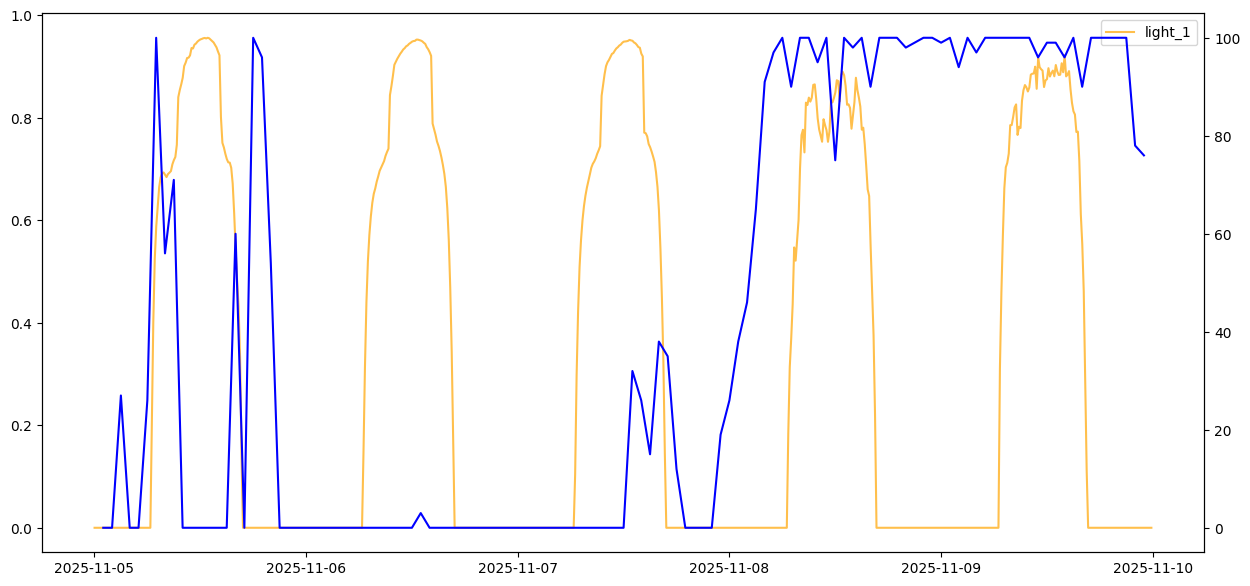

In [88]:
start_date = dt.datetime(2025,11,5)
end_date = dt.datetime(2025,11,10)
plot_df = ardu_df.filter(pl.col('timestamp') > start_date, pl.col('timestamp') < end_date)
plot_2_df = o_df.filter(pl.col('timestamp') > start_date, pl.col('timestamp') < end_date)
fig, ax = plt.subplots(figsize= (15, 7))
ax.twinx().plot(plot_2_df['timestamp'], plot_2_df['cloud_cover'], label='cloud', color='blue')
ax.plot(plot_df['timestamp'], (((plot_df['light_1']) * 1.06 / 4095) ** 0.5), label='light_1', color='orange', alpha=0.7)
# ax.plot(plot_df['timestamp'], ((plot_df['light_2']  / 4095)) ** 0.5, label='light_2')
ax.legend()

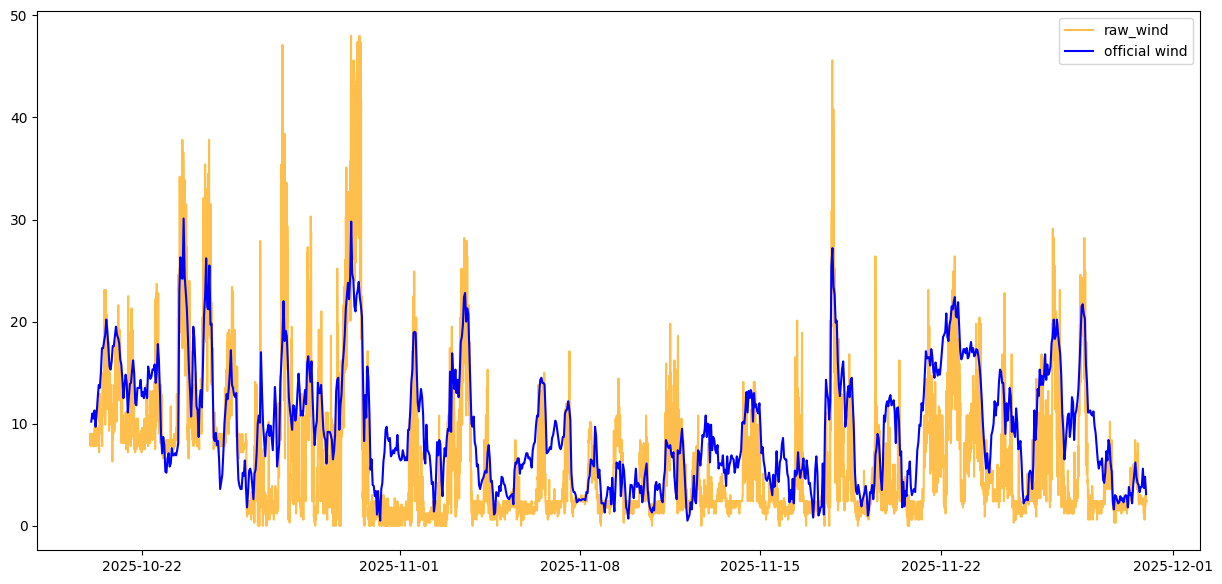

In [107]:
start_date = dt.datetime(2025,10,20)
end_date = dt.datetime(2025,11,30)
plot_df = ardu_df.filter(pl.col('timestamp') > start_date, pl.col('timestamp') < end_date)
plot_2_df = o_df.filter(pl.col('timestamp') > start_date, pl.col('timestamp') < end_date)
fig, ax = plt.subplots(figsize= (15, 7))
ax.plot(plot_df['timestamp'], plot_df['wind'] * 6, label='raw_wind', color='orange', alpha=0.7)
ax.plot(plot_2_df['timestamp'], plot_2_df['wind_speed_10m'], label='official wind', color='blue')
# ax.plot(plot_df['timestamp'], ((plot_df['light_2']  / 4095)) ** 0.5, label='light_2')
ax.legend()
# ax.plot(plot_df['timestamp'], plot_df['raw_wind'], label='raw wind')